# Geração de Imagens e Treinamento Ângulo-Ordem (Order-CWT)

**Projeto:** Diagnóstico de Falhas em Rolamentos via CWT + Deep Learning  
**Metodologia:** Computed Order Tracking (COT) + Continuous Wavelet Transform  
**Objetivo:** Gerar escalogramas no domínio de ordens (amostras uniformes por volta do eixo) e treinar as arquiteturas convolucionais (`BearingCNN` e `ResNet-18`) com invariância à rotação (RPM).

---

## 1. Importação de Módulos e Configurações

In [8]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent.parent if Path.cwd().name == '4_order_tracking' else Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.insert(0, str(BASE_DIR))

import torch
from src.config import (
    ORDER_CWRU_DIR,
    ORDER_PADERBORN_DIR,
    RANDOM_SEED,
    NUM_EPOCHS,
    LEARNING_RATE
)
from src.generate_order_dataset import generate_all_order_datasets
from src.transfer_learning import train_and_evaluate_transfer_model
from src.visualization import plot_training_curves, plot_confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'[INFO] Dispositivo de treinamento: {device}')


[INFO] Dispositivo de treinamento: cuda


## 2. Geração Automática dos Escalogramas Ângulo-Ordem (Order-CWT)

Gera os datasets em `data/order_tracking/cwru/` e `data/order_tracking/paderborn/` sem Data Leakage.

In [2]:
# Executa o pipeline completo com normalização GLOBAL (Two-Pass + Z-Score)
generate_all_order_datasets(max_files_per_class=10)


[Z-SCORE] Calculando estatísticas globais do CWRU...
    CWRU global: mean=0.008482, std=0.299433 (6088536 amostras)
[Z-SCORE] Calculando estatísticas globais do Paderborn...
    Paderborn global: mean=0.023546, std=0.230415 (7683391 amostras)
[PASS 1] Estimando vmin/vmax globais do CWRU Order-CWT...
    CWRU Order-CWT estimado: vmin=0.007111, vmax=1.816011
[PASS 1] Estimando vmin/vmax globais do Paderborn Order-CWT...
    Paderborn Order-CWT estimado: vmin=0.015150, vmax=2.688748

[GLOBAL COMPARTILHADO] vmin=0.007111, vmax=2.688748

 GERAÇÃO DO DATASET ÂNGULO-ORDEM (ORDER-CWT) — CWRU [GLOBAL NORM]
    1024 amostras/volta | Janela: 4 voltas | Ordens: 0.5-15.0
    Z-Score: mean=0.0085, std=0.2994
    Colormap Norm: vmin=0.007111, vmax=2.688748
    ✅ CWRU     normal (train): 2 arquivos -> 889 imagens geradas
    ✅ CWRU     normal (  val): 1 arquivos -> 594 imagens geradas
    ✅ CWRU     normal ( test): 1 arquivos -> 582 imagens geradas
    ✅ CWRU inner_race (train): 8 arquivos -> 1178 im

## 3. Treinamento da ResNet-18 no Dataset CWRU Ângulo-Ordem

[INFO] EXPERIMENTO TRANSFER LEARNING: RESNET18 | Freeze=False | Épocas=10 | LR=0.0001
Época [01/10] | Treino Loss: 0.0742 - Acc: 97.33% | Val Loss: 0.0059 - Acc: 99.93% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0059 - Acc: 99.91% | Val Loss: 0.0019 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0053 - Acc: 99.80% | Val Loss: 0.0017 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 03/10.
Época [04/10] | Treino Loss: 0.0082 - Acc: 99.82% | Val Loss: 0.0002 - Acc: 100.00% [CHECKPOINT] Modelo ótimo salvo na época 04/10.
Época [05/10] | Treino Loss: 0.0014 - Acc: 99.98% | Val Loss: 0.0004 - Acc: 100.00% 
Época [06/10] | Treino Loss: 0.0008 - Acc: 100.00% | Val Loss: 0.0004 - Acc: 100.00% 
Época [07/10] | Treino Loss: 0.0017 - Acc: 99.95% | Val Loss: 0.0007 - Acc: 100.00% 
Época [08/10] | Treino Loss: 0.0004 - Acc: 100.00% | Val Loss: 0.0002 - Acc: 100.00% 
Época [09/10] | Treino Loss: 0.0005 - Acc: 99

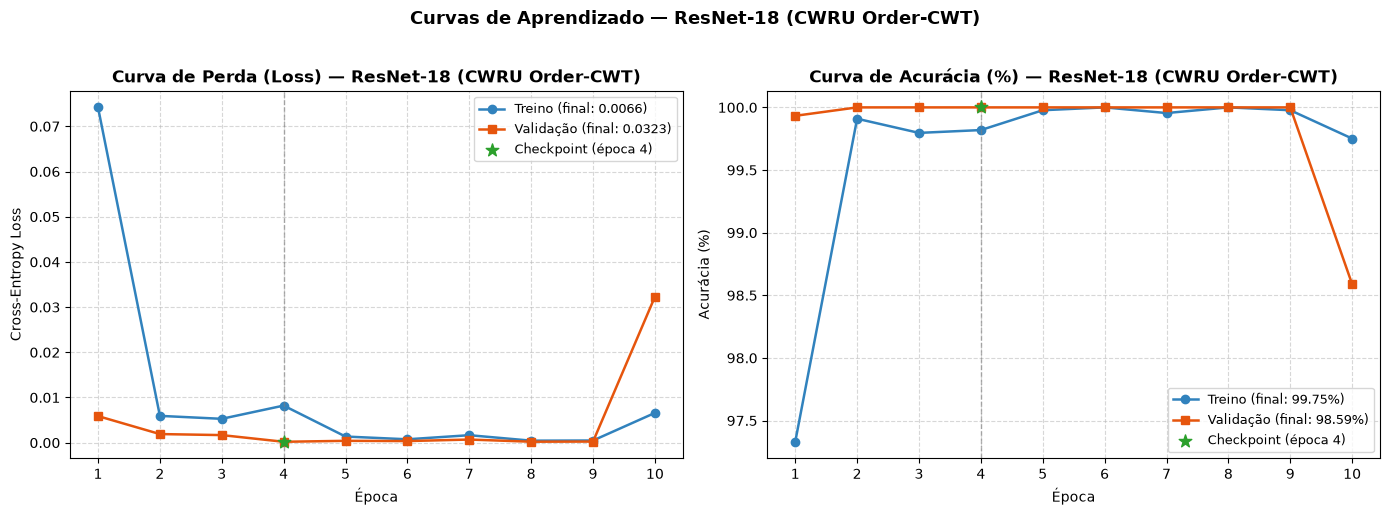

[INFO] Figura salva em: ../../docs/images/confusion_matrix_order_cwru_resnet.png


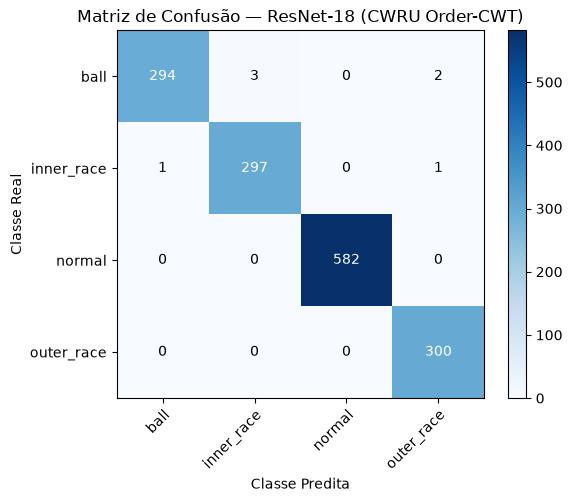

In [9]:
res_cwru_order = train_and_evaluate_transfer_model(
    model_name="resnet18",
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    freeze=False,
    data_dir=ORDER_CWRU_DIR,
    checkpoint_prefix="checkpoint_order_cwru"
)

plot_training_curves(
    res_cwru_order['history'],
    model_name="ResNet-18 (CWRU Order-CWT)",
    save_path="../../docs/images/training_curves_order_cwru_resnet.png"
)

plot_confusion_matrix(
    res_cwru_order,
    model_name="ResNet-18 (CWRU Order-CWT)",
    save_path="../../docs/images/confusion_matrix_order_cwru_resnet.png"
)

## 4. Treinamento da ResNet-18 no Dataset Paderborn Ângulo-Ordem

[INFO] EXPERIMENTO TRANSFER LEARNING: RESNET18 | Freeze=False | Épocas=10 | LR=0.0001
Época [01/10] | Treino Loss: 0.3864 - Acc: 82.76% | Val Loss: 0.6942 - Acc: 80.46% [CHECKPOINT] Modelo ótimo salvo na época 01/10.
Época [02/10] | Treino Loss: 0.0635 - Acc: 97.54% | Val Loss: 0.1191 - Acc: 95.40% [CHECKPOINT] Modelo ótimo salvo na época 02/10.
Época [03/10] | Treino Loss: 0.0454 - Acc: 98.03% | Val Loss: 0.2635 - Acc: 91.95% 
Época [04/10] | Treino Loss: 0.0142 - Acc: 99.51% | Val Loss: 0.3890 - Acc: 89.66% 
Época [05/10] | Treino Loss: 0.0158 - Acc: 99.34% | Val Loss: 0.0730 - Acc: 97.70% [CHECKPOINT] Modelo ótimo salvo na época 05/10.
Época [06/10] | Treino Loss: 0.0090 - Acc: 99.84% | Val Loss: 0.0907 - Acc: 96.55% 
Época [07/10] | Treino Loss: 0.0089 - Acc: 99.84% | Val Loss: 0.1457 - Acc: 94.25% 
Época [08/10] | Treino Loss: 0.0093 - Acc: 99.67% | Val Loss: 0.0697 - Acc: 97.70% [CHECKPOINT] Modelo ótimo salvo na época 08/10.
Época [09/10] | Treino Loss: 0.0083 - Acc: 99.84% | Va

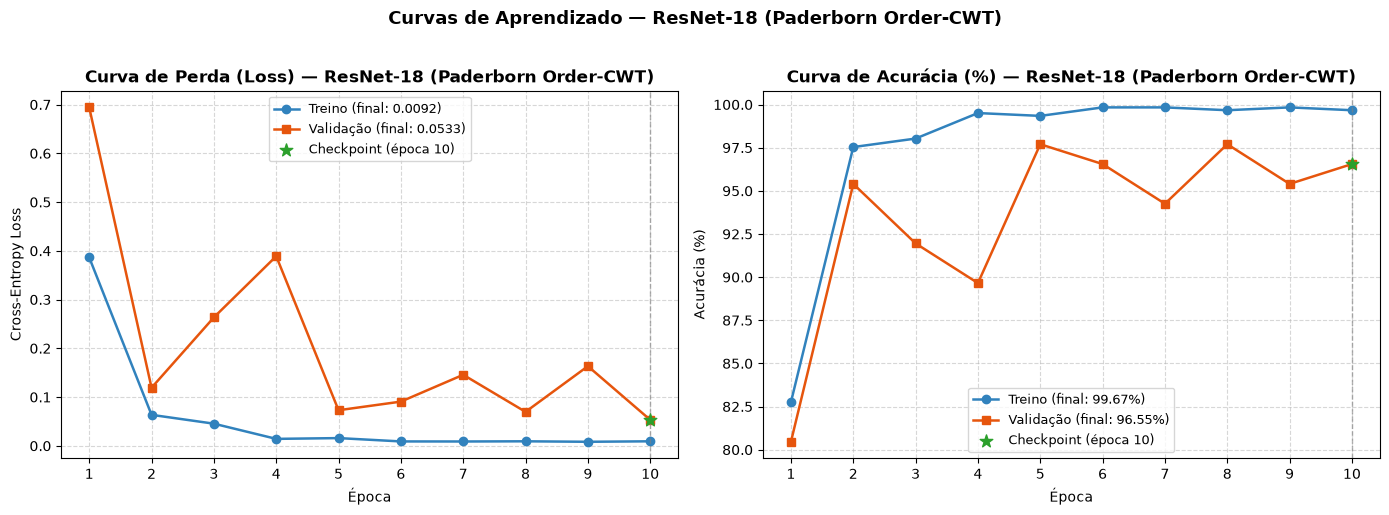

[INFO] Figura salva em: ../../docs/images/confusion_matrix_order_paderborn_resnet.png


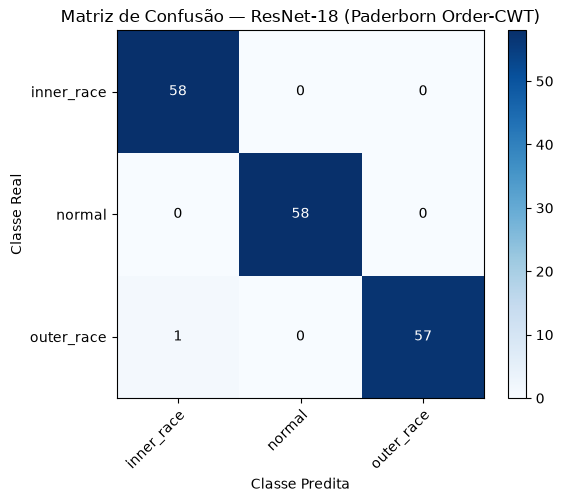

In [10]:
res_pad_order = train_and_evaluate_transfer_model(
    model_name="resnet18",
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    freeze=False,
    data_dir=ORDER_PADERBORN_DIR,
    checkpoint_prefix="checkpoint_order_paderborn"
)

plot_training_curves(
    res_pad_order['history'],
    model_name="ResNet-18 (Paderborn Order-CWT)",
    save_path="../../docs/images/training_curves_order_paderborn_resnet.png"
)

plot_confusion_matrix(
    res_pad_order,
    model_name="ResNet-18 (Paderborn Order-CWT)",
    save_path="../../docs/images/confusion_matrix_order_paderborn_resnet.png"
)